Imports and Data Loading

In [1]:
import numpy as np
import pandas as pd
import os
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

X_train = np.load('../data/processed/X_train.npy')
y_train = np.load('../data/processed/y_train.npy')
X_val = np.load('../data/processed/X_val.npy')
y_val = np.load('../data/processed/y_val.npy')

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val.shape}")

# Calculate number of input features based on preprocessing
num_features = X_train.shape[1]

X_train shape: (30693, 9)
y_train shape: (30693, 1)
X_val shape: (6577, 9)
y_val shape: (6577, 1)


MLP ANN Architecture

In [9]:
# # FIRST MODEL: 3 Hidden Layers with Dropout
# model = keras.Sequential([
# # Input Layer
#     keras.layers.Dense(16, activation='relu', input_shape=(num_features,)),
#     keras.layers.Dropout(0.2),

# # Hidden Layer 2
#     keras.layers.Dense(12, activation='relu'),
#     keras.layers.Dropout(0.2),

# # Hidden Layer 3
#     keras.layers.Dense(8, activation='relu'),

# # Output Layer (1 continuous output: kWh)
#     keras.layers.Dense(1, activation='linear')
# ])

# # Compile
# model.compile(
#     optimizer=keras.optimizers.Adam(learning_rate=0.001),
#     loss='mse',
#     metrics=['mae']
# )

# SECOND MODEL: Wider Layers with LeakyReLU and Huber Loss
model = keras.Sequential([
#Input Layer
    keras.layers.Dense(32, input_shape=(num_features,)),
    keras.layers.LeakyReLU(alpha=0.1),
    keras.layers.Dropout(0.15),

# Hidden Layer 2
    keras.layers.Dense(24),
    keras.layers.LeakyReLU(alpha=0.1),
    keras.layers.Dropout(0.15),

# Hidden Layer 3
    keras.layers.Dense(16),
    keras.layers.LeakyReLU(alpha=0.1),

# Output Layer
    keras.layers.Dense(1, activation='linear')
])

# Compile the model w/ Huber Loss
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.Huber(delta=1.0), # Better for noisy weather data than MSE
    metrics=['mae', 'mse'] 
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 32)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 24)             │           792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,529 (5.97 KB)

 Trainable params: 1,529 (5.97 KB)

 Non-trainable params: 0 (0.00 B)

Configuring Callbacks

In [10]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', 
        patience=15, 
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath='../models/best_model_iloilo.h5',
        monitor='val_loss', 
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', 
        factor=0.5, 
        patience=7, 
        min_lr=1e-6,
        verbose=1
    )
]

Training the Model

In [11]:
history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)

Epoch 1/200
910/960 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0187 - mae: 0.1391 - mse: 0.0374
Epoch 1: val_loss improved from None to 0.00590, saving model to ../models/best_model_iloilo.h5



Epoch 1: finished saving model to ../models/best_model_iloilo.h5
960/960 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0112 - mae: 0.1035 - mse: 0.0225 - val_loss: 0.0059 - val_mae: 0.0721 - val_mse: 0.0118 - learning_rate: 0.0010
Epoch 2/200
956/960 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0068 - mae: 0.0780 - mse: 0.0136
Epoch 2: val_loss improved from 0.00590 to 0.00481, saving model to ../models/best_model_iloilo.h5



Epoch 2: finished saving model to ../models/best_model_iloilo.h5
960/960 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0063 - mae: 0.0751 - mse: 0.0126 - val_loss: 0.0048 - val_mae: 0.0622 - val_mse: 0.0096 - learning_rate: 0.0010
Epoch 3/200
918/960 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0055 - mae: 0.0691 - mse: 0.0110
Epoch 3: val_loss improved from 0.00481 to 0.00410, saving model to ../models/best_model_iloilo.h5



Epoch 3: finished saving model to ../models/best_model_iloilo.h5
960/960 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0053 - mae: 0.0670 - mse: 0.0106 - val_loss: 0.0041 - val_mae: 0.0548 - val_mse: 0.0082 - learning_rate: 0.0010
Epoch 4/200
933/960 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0049 - mae: 0.0630 - mse: 0.0098
Epoch 4: val_loss improved from 0.00410 to 0.00374, saving model to ../models/best_model_iloilo.h5



Epoch 4: finished saving model to ../models/best_model_iloilo.h5
960/960 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0048 - mae: 0.0619 - mse: 0.0095 - val_loss: 0.0037 - val_mae: 0.0501 - val_mse: 0.0075 - learning_rate: 0.0010
Epoch 5/200
940/960 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0044 - mae: 0.0588 - mse: 0.0087
Epoch 5: val_loss did not improve from 0.00374
960/960 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0044 - mae: 0.0591 - mse: 0.0088 - val_loss: 0.0038 - val_mae: 0.0523 - val_mse: 0.0076 - learning_rate: 0.0010
Epoch 6/200
951/960 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0043 - mae: 0.0579 - mse: 0.0087
Epoch 6: val_loss did not improve from 0.00374
960/960 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0042 - mae: 0.0569 - mse: 0.0084 - val_loss: 0.0038 - val_mae: 0.0504 - val_mse: 0.0076 - learning_rate: 0.0010
Epoch 7/200
948/960 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0042 - mae: 0.0564 - mse: 0.0083
Epoch 7: val_loss improved from 0.00374 to 0.00349, saving mode


Epoch 7: finished saving model to ../models/best_model_iloilo.h5
960/960 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0041 - mae: 0.0558 - mse: 0.0082 - val_loss: 0.0035 - val_mae: 0.0449 - val_mse: 0.0070 - learning_rate: 0.0010
Epoch 8/200
932/960 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0041 - mae: 0.0550 - mse: 0.0081
Epoch 8: val_loss did not improve from 0.00349
960/960 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0040 - mae: 0.0546 - mse: 0.0081 - val_loss: 0.0037 - val_mae: 0.0469 - val_mse: 0.0073 - learning_rate: 0.0010
Epoch 9/200
948/960 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0039 - mae: 0.0536 - mse: 0.0079
Epoch 9: val_loss improved from 0.00349 to 0.00336, saving model to ../models/best_model_iloilo.h5



Epoch 9: finished saving model to ../models/best_model_iloilo.h5
960/960 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0039 - mae: 0.0533 - mse: 0.0078 - val_loss: 0.0034 - val_mae: 0.0488 - val_mse: 0.0067 - learning_rate: 0.0010
Epoch 10/200
958/960 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0039 - mae: 0.0528 - mse: 0.0078
Epoch 10: val_loss did not improve from 0.00336
960/960 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 0.0038 - mae: 0.0521 - mse: 0.0077 - val_loss: 0.0036 - val_mae: 0.0452 - val_mse: 0.0071 - learning_rate: 0.0010
Epoch 11/200
950/960 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0037 - mae: 0.0513 - mse: 0.0075
Epoch 11: val_loss did not improve from 0.00336
960/960 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0038 - mae: 0.0513 - mse: 0.0075 - val_loss: 0.0035 - val_mae: 0.0474 - val_mse: 0.0070 - learning_rate: 0.0010
Epoch 12/200
923/960 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0038 - mae: 0.0513 - mse: 0.0077
Epoch 12: val_loss did not improve from 0.00336
960/960 ━━

In [12]:
best_epoch = np.argmin(history.history['val_loss'])

best_val_loss = history.history['val_loss'][best_epoch]
best_val_mae = history.history['val_mae'][best_epoch]
best_train_loss = history.history['loss'][best_epoch]
best_train_mae = history.history['mae'][best_epoch]

print(f"Best Epoch: {best_epoch + 1}")
print(f"Training Loss (MSE): {best_train_loss:.5f}")
print(f"Training MAE:        {best_train_mae:.5f}")
print(f"Validation Loss (MSE): {best_val_loss:.5f}")
print(f"Validation MAE:        {best_val_mae:.5f}")

Best Epoch: 9
Training Loss (MSE): 0.00392
Training MAE:        0.05335
Validation Loss (MSE): 0.00336
Validation MAE:        0.04878


Training History Plot

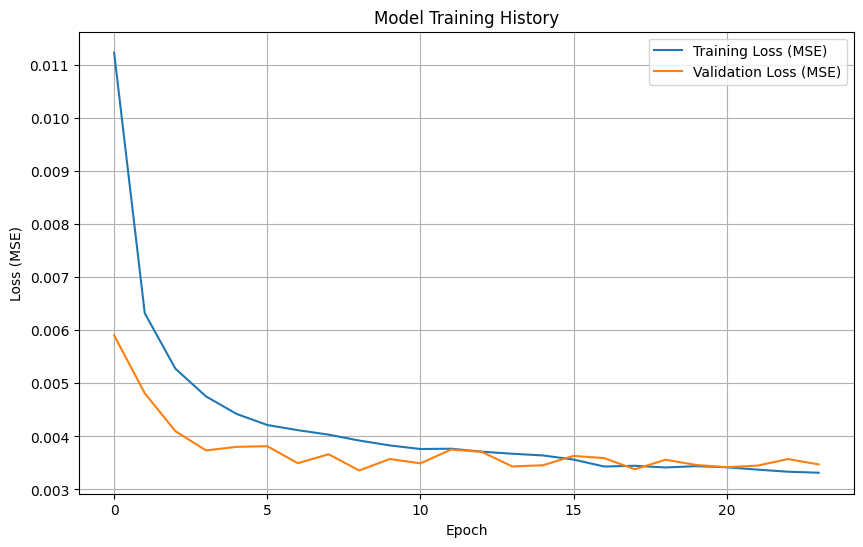

In [13]:
os.makedirs('../figures', exist_ok=True)
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss (MSE)')
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)')
plt.title('Model Training History')
plt.ylabel('Loss (MSE)')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)
plt.savefig('../figures/training_loss_curve.png', dpi=300, bbox_inches='tight')
plt.show()